# M1 — The Solar Spectrum, the Excitation Grid, and the Inelastic Truth Data

Milestone M1 of the inelastic coding plan
([`design/rt_inelastic_model_coding_plan.md`](../../design/rt_inelastic_model_coding_plan.md)):
everything the analytic terms (M2) and the correction heads (M3) will *consume* now
exists and is tested — the packaged solar spectra and their `Geometry.Ed` override
(`robust/rt/ed.py`), the Raman excitation-grid machinery
(`robust/rt/conventions.py`), and the X2/X4 data pipeline with truth channels on the
elastic splits (`robust/rt/data/l23.py`). This notebook explains what M1 *decided*
and shows the data those decisions rest on.

| M | Goal |
|---|------|
| M0 | Environment & API extension ([notebook 1](rt_inelastic_coding_1.ipynb)) |
| **M1** | **Ed, excitation grid, X2/X4 truth data — this notebook** |
| M2 | Analytic Raman & fluorescence terms in JAX |
| M3 | Correction heads δ_R, δ_F |
| M4 | Validation — prototype done |

The quantitative *assessment* behind every choice here — BING's inelastic
formulation scored against these same scenario pairs — is
[`context/RT/rt_inelastic_bing_summary.md`](../../context/RT/rt_inelastic_bing_summary.md)
with its committed figures (`fig_raman_bing_vs_l23.png`,
`fig_fluor_bing_vs_l23.png`, `fig_l23_inelastic_impact.png`); this notebook links
to those results rather than re-deriving them. Everything below runs from
**committed files only** (the packaged `ed_l23.npz` and the two CI fixtures) — no
`$OS_COLOR` needed.

In [1]:
import sys
from pathlib import Path

# notebooks/RT/ -> repo root on sys.path (robust is not pip-installed here).
REPO = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / 'robust' / '__init__.py').exists())
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

import jax
import numpy as np

from robust.rt import conventions as C
from robust.rt import ed as E
from robust.rt.data import l23 as L
from robust.tests.conftest import L23_INELASTIC_FIXTURE, L23_SMALL_FIXTURE

print(f'repo: {REPO}')
print(f'jax {jax.__version__} on {jax.default_backend()}')


An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


repo: /mnt/tank/Oceanography/python/retrieve-or-bust
jax 0.11.1 on cpu


## 1. The packaged sky

The Raman term needs the true ratio `Ed(λ′)/Ed(λ)` and the fluorescence term needs
`Ed(λ′)` inside its excitation quadrature — so M1 packages the L23 downwelling
irradiance as data (`robust/rt/data/ed_l23.npz`, 2 kB). Two properties were
*asserted before packaging*, not assumed (`design/py/gen_inelastic_fixture.py`):

- **Ed is a sky property**: across each file's 3320 scenes the relative scatter is
  ~5×10⁻⁵ (float32 storage noise), a factor ~20 inside the coding plan's 10⁻³ gate.
- **Ed is scenario-independent**: X=1/2/4 carry bit-identical irradiance at fixed
  zenith — the generator stops rather than average different suns.

The recorded caveat (design DQ5, JXP): reference solar models are themselves
imperfect, so v1 deliberately inherits *whatever HydroLight used* — consistency
with the truth data over absolute solar accuracy. The `Geometry.Ed` override is
the seam where real skies (TSIS-era, PACE) enter later, with no interface change.

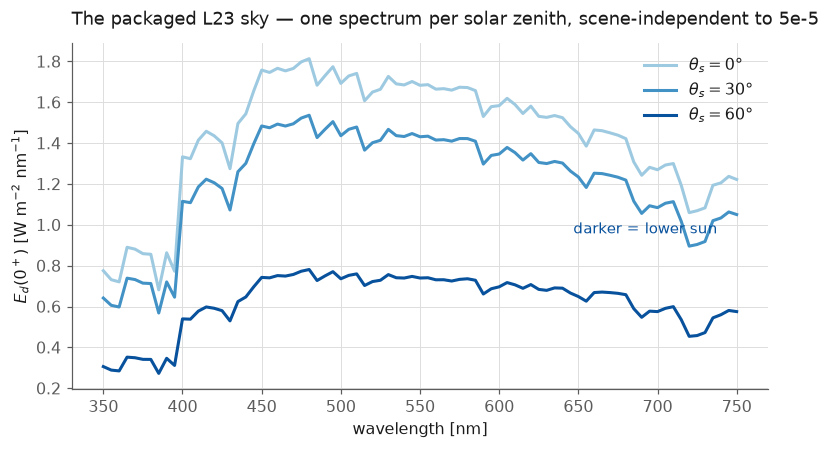

Ed(440): {'0°': '1.5435', '30°': '1.3010', '60°': '0.6467'}


In [2]:
import matplotlib as mpl
import matplotlib.pyplot as plt

# --- house style (elastic notebook 1) ---
INK, INK_MUTED, GRID = '#1a1a1a', '#5c5c5c', '#dcdcdc'
BLUES = {0.0: '#9ecae1', 30.0: '#4292c6', 60.0: '#08519c'}
ORANGE = '#D55E00'
mpl.rcParams.update({
    'figure.dpi': 110, 'savefig.dpi': 110, 'font.size': 10.5,
    'axes.edgecolor': INK_MUTED, 'axes.labelcolor': INK, 'text.color': INK,
    'xtick.color': INK_MUTED, 'ytick.color': INK_MUTED,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.color': GRID, 'grid.linewidth': 0.6,
    'legend.frameon': False, 'figure.facecolor': 'white', 'axes.facecolor': 'white',
})

wave_ed, ed_table = E.load_table()

fig, ax = plt.subplots(figsize=(7.2, 4.2))
for row, (theta, color) in enumerate(BLUES.items()):
    ax.plot(wave_ed, ed_table[row], color=color, lw=2.0,
            label=f'$\\theta_s = {theta:.0f}°$')
ax.set_xlabel('wavelength [nm]')
ax.set_ylabel(r'$E_d(0^+)$ [W m$^{-2}$ nm$^{-1}$]')
ax.set_title("The packaged L23 sky — one spectrum per solar zenith, "
             "scene-independent to 5e-5", fontsize=11.5, pad=12, loc='left')
ax.legend(loc='upper right')
ax.annotate('darker = lower sun', xy=(0.72, 0.45), xycoords='axes fraction',
            color='#08519c', fontsize=9.5)
fig.tight_layout()
plt.show()

print('Ed(440):', {f'{t:.0f}°': f'{ed_table[i][np.abs(wave_ed-440).argmin()]:.4f}'
                   for i, t in enumerate(BLUES)})


The spectral *structure* — Fraunhofer lines, the ozone and water-vapor features,
the blue peak — is the point, and it is exactly what a "flat Ed" assumption throws
away. Between the anchors `ed.Ed(θ_s, λ)` interpolates linearly in `θ_s` and
**clamps** outside 0–60° and outside 350–750 nm (the `bb_w` precedent: no silent
extrapolation, no error under `jit`).

## 2. The ratio the Raman term actually consumes

Raman emission at λ was excited at
`λ′ = raman_excitation(λ)`, the 3400 cm⁻¹ wavenumber shift
(`1/λ′ = 1/λ + 3400 cm⁻¹` — e.g. 685 nm emission was pumped at ~561 nm, and 488 nm
at 418.55 nm). The correction therefore scales with `Ed(λ′)/Ed(λ)` — how much more
(or less) sunlight there was at the pump wavelength than at the emission
wavelength. The official support starts at λ = 400 nm because
`raman_excitation(400) = 352.11 nm`, just inside the L23 grid; below that the maps
run but the excitation IOPs clamp (documented caveat, not a gate).

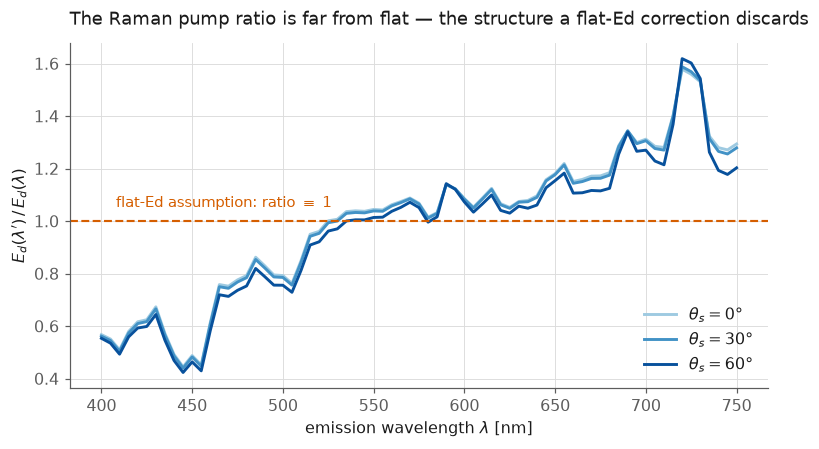

ratio at 30°: min 0.440 at 445 nm, max 1.588 at 720 nm (span x3.61)


In [3]:
wave_em = C.WAVE[C.WAVE >= C.RAMAN_WAVE_MIN_OFFICIAL]
wave_ex = C.raman_excitation(wave_em)

fig, ax = plt.subplots(figsize=(7.2, 4.2))
for theta, color in BLUES.items():
    r = np.asarray(E.ratio(theta, wave_ex, wave_em))
    ax.plot(wave_em, r, color=color, lw=1.9, label=f'$\\theta_s = {theta:.0f}°$')
ax.axhline(1.0, color=ORANGE, lw=1.4, ls='--')
ax.text(408, 1.035, 'flat-Ed assumption: ratio $\\equiv$ 1', color=ORANGE,
        fontsize=9.5, va='bottom')

ax.set_xlabel('emission wavelength $\\lambda$ [nm]')
ax.set_ylabel(r"$E_d(\lambda')\,/\,E_d(\lambda)$")
ax.set_title("The Raman pump ratio is far from flat — the structure a flat-Ed "
             "correction discards", fontsize=11.5, pad=12, loc='left')
ax.legend(loc='lower right')
fig.tight_layout()
plt.show()

r30 = np.asarray(E.ratio(30.0, wave_ex, wave_em))
print(f'ratio at 30°: min {r30.min():.3f} at {wave_em[r30.argmin()]:.0f} nm, '
      f'max {r30.max():.3f} at {wave_em[r30.argmax()]:.0f} nm '
      f'(span x{r30.max()/r30.min():.2f})')


The ratio swings by more than a factor of two across the official band and is
nearly zenith-independent (the sky's *shape* barely changes with sun angle — its
*amplitude* does, and amplitude cancels in the ratio). This is the quantitative
reason the assessment found BING's flat-Ed Raman increment wrong by **+60 % in the
blue to −50 % in the red** even though its two-flow machinery was sound — see the
assessment's `fig_raman_bing_vs_l23.png` and §"true Ed ratio" of
[`rt_inelastic_bing_summary.md`](../../context/RT/rt_inelastic_bing_summary.md).
M2's `raman_factor` consumes `ed.ratio` directly, and the M1 API guarantees the
numerator and denominator always come from the *same* sky (packaged or override —
never mixed).

## 3. The truth channels, across trophic states

The L23 release is three *paired* radiative-transfer configurations of the same
3320 water bodies: X1 (elastic), X2 (+Raman), X4 (+Raman +fluorescence at
`phi_C = 0.02`). Their differences are **exact truth** for each process
separately:

- `Rrs_X2 / Rrs_X1` — the Raman correction factor `f_R` (what M2's analytic
  `f_phys` and M3's corrected `f_R` are scored against);
- `Rrs_X4 − Rrs_X2` — the additive fluorescence term at exactly `PHI_C_L23`.

The loader (`l23.load_inelastic_batch`) reads the IOPs once and *asserts* they are
bit-identical across scenarios (measured, not assumed), and the committed sibling
fixture reproduces all of this in CI. Below: the two truth channels for three
scenes spanning the trophic range, picked by `a_ph(440)` from the fixture's 50.

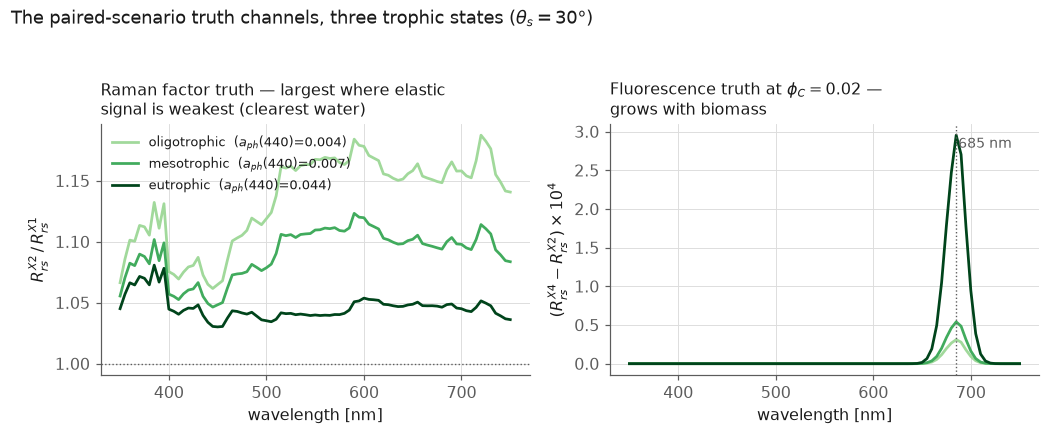

Raman factor over the fixture: min 1.0156 (never < 1), max 1.36
fluorescence delta at 685 nm: all positive = True


In [4]:
batch = L.load_inelastic_batch(
    reader=L.inelastic_npz_reader(L23_INELASTIC_FIXTURE, L23_SMALL_FIXTURE))
wave = np.asarray(batch.wave)

# Three trophic states at theta_s = 30°, by a_ph(440) percentile.
at30 = np.flatnonzero(batch.zenith == 30.0)
aph440 = np.asarray(batch.iops.a_ph)[at30, np.abs(wave - 440).argmin()]
order = at30[np.argsort(aph440)]
picks = {'oligotrophic': order[0], 'mesotrophic': order[len(order) // 2],
         'eutrophic': order[-1]}
GREENS = dict(zip(picks, ['#a1d99b', '#41ab5d', '#00441b']))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9.6, 4.0))
for (label, i), color in zip(picks.items(), GREENS.values()):
    aph = np.asarray(batch.iops.a_ph)[i, np.abs(wave - 440).argmin()]
    ax1.plot(wave, np.asarray(batch.truth_raman_factor)[i], color=color, lw=1.8,
             label=f'{label}  ($a_{{ph}}(440)$={aph:.3f})')
    ax2.plot(wave, 1e4 * np.asarray(batch.truth_fluorescence)[i], color=color,
             lw=1.8)
ax1.axhline(1.0, color=INK_MUTED, lw=0.9, ls=':')
ax1.set_xlabel('wavelength [nm]')
ax1.set_ylabel(r'$R_{rs}^{X2}\,/\,R_{rs}^{X1}$')
ax1.set_title('Raman factor truth — largest where elastic\nsignal is weakest (clearest water)', fontsize=10.5, loc='left')
ax1.legend(loc='upper left', fontsize=8.5)
ax2.axvline(685, color=INK_MUTED, lw=0.9, ls=':')
ax2.text(687, ax2.get_ylim()[1] * 0.9, '685 nm', color=INK_MUTED, fontsize=9)
ax2.set_xlabel('wavelength [nm]')
ax2.set_ylabel(r'$(R_{rs}^{X4} - R_{rs}^{X2}) \times 10^4$')
ax2.set_title('Fluorescence truth at $\\phi_C = 0.02$ —\ngrows with biomass',
              fontsize=10.5, loc='left')
fig.suptitle('The paired-scenario truth channels, three trophic states '
             '($\\theta_s = 30°$)', x=0.01, ha='left', fontsize=11.5)
fig.tight_layout(rect=(0, 0, 1, 0.94))
plt.show()

factor = np.asarray(batch.truth_raman_factor)
print(f'Raman factor over the fixture: min {factor.min():.4f} (never < 1), '
      f'max {factor.max():.2f}')
i685 = int(np.abs(wave - 685).argmin())
print(f'fluorescence delta at 685 nm: all positive = '
      f'{bool((np.asarray(batch.truth_fluorescence)[:, i685] > 0).all())}')


How big each process is, in one sentence each: **Raman** multiplies `Rrs` by
up to 1.36 across the fixture's 50 scenes — and up to **2.5** over the full 3320
(the pipeline tests pin both bounds) — smallest in the blue where elastic
scattering dominates, largest in the red of *clear* water where almost no
elastically scattered photons survive (hence the oligotrophic curve on top); the
per-wavelength impact map is the assessment's `fig_l23_inelastic_impact.png`.
**Fluorescence** adds a narrow 685 nm peak that grows with biomass — order 10⁻⁵–10⁻⁴
sr⁻¹ at `phi_C = 0.02`, which can *double* the total red signal in eutrophic water
(the assessment's `fig_fluor_bing_vs_l23.png` shows BING's single-Gaussian shape
against this same truth). Both processes are why the inelastic effort exists: an
elastic-only forward model is structurally wrong in the red.

## 4. Split reuse — the property M3's gates stand on

The per-process gates (M3: median |error| ≤ 5 % on *held-out* scenes) are only
meaningful if "held out" means the **same** held-out scenes as the elastic effort.
Mechanically that is `make_splits` reading only the `scene`/`zenith` labels, and
the inelastic loader reproducing the elastic layout exactly — proved below,
mask for mask, and by the test suite at both fixture and full-release scale.

In [5]:
elastic = L.load_batch(reader=L.npz_reader(L23_SMALL_FIXTURE))
s_el = L.make_splits(elastic)
s_in = L.make_splits(batch)

print('same held-out scenes  :',
      bool(np.array_equal(s_in.test_scenes, s_el.test_scenes)),
      f'  (n = {s_in.test_scenes.size}, seed = {L.SPLIT_SEED})')
for field in ('scene_train', 'scene_test', 'zenith_train', 'zenith_test'):
    same = bool(np.array_equal(getattr(s_in, field), getattr(s_el, field)))
    print(f'{field:<13}: identical mask = {same}')

# And the shared data really is shared, bit for bit:
print('Rrs_x1 == elastic Rrs :',
      bool(np.array_equal(np.asarray(batch.Rrs_x1), np.asarray(elastic.Rrs))))


same held-out scenes  : True   (n = 10, seed = 23)
scene_train  : identical mask = True
scene_test   : identical mask = True
zenith_train : identical mask = True
zenith_test  : identical mask = True
Rrs_x1 == elastic Rrs : True


## 5. Where this leaves us

The M1 gate is green — 355 tests, including the recurring elastic
hash-regression, the golden netCDF cross-checks, the CQ4 byte-pin on the elastic
fixture, and the split-equality proofs (`design/rt_inelastic_implementation.md`
§3 for the full record; §3.2.1 for the PR #14 review debt this milestone also
cleared).

**M2 next**: the analytic terms — `raman_factor` (Bartlett b_R, single-shift
excitation grid, S&P98 two-flow, the true `ed.ratio`) and `fluorescence_kernel`
(`b_F = a_ph(λ′)` source, 370–690 nm quadrature) — ported from fixed BING to
differentiable JAX, cross-checked *live* against the `inelastic-fixes` checkout
at rtol ≤ 1e-6, and characterized against the truth channels shown above.